In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("../data/clean_nypd_arrests_data.csv")

# Quick check
print(df.shape)     # rows, columns
print(df.head())    # preview first 5 rows

(155507, 14)
   ARREST_KEY ARREST_DATE                   PD_DESC OFNS_DESC   LAW_CAT_CD  \
0   222488045  2021-01-01                 ASSAULT 3   ASSAULT  MISDEMEANOR   
1   222488087  2021-01-01                 ASSAULT 3   ASSAULT  MISDEMEANOR   
2   222487994  2021-01-01  ASSAULT 2,1,UNCLASSIFIED   ASSAULT       FELONY   
3   222488113  2021-01-01                 ASSAULT 3   ASSAULT  MISDEMEANOR   
4   222500383  2021-01-01                 ASSAULT 3   ASSAULT  MISDEMEANOR   

     ARREST_BORO  ARREST_PRECINCT AGE_GROUP PERP_SEX       PERP_RACE  \
0       BROOKLYN               83     25-44     MALE  WHITE HISPANIC   
1         QUEENS              104     25-44     MALE  WHITE HISPANIC   
2          BRONX               52     25-44     MALE  WHITE HISPANIC   
3  STATEN ISLAND              121     25-44   FEMALE           BLACK   
4       BROOKLYN               72     25-44     MALE  WHITE HISPANIC   

    Latitude  Longitude                       New Georeferenced Column  \
0  40.69699

In [2]:
df.info()   # preview dataframe info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155507 entries, 0 to 155506
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ARREST_KEY                155507 non-null  int64  
 1   ARREST_DATE               155507 non-null  object 
 2   PD_DESC                   155507 non-null  object 
 3   OFNS_DESC                 155507 non-null  object 
 4   LAW_CAT_CD                155507 non-null  object 
 5   ARREST_BORO               155507 non-null  object 
 6   ARREST_PRECINCT           155507 non-null  int64  
 7   AGE_GROUP                 155507 non-null  object 
 8   PERP_SEX                  155507 non-null  object 
 9   PERP_RACE                 155507 non-null  object 
 10  Latitude                  155507 non-null  float64
 11  Longitude                 155507 non-null  float64
 12  New Georeferenced Column  155507 non-null  object 
 13  MONTH                     155507 non-null  o

In [3]:
df.describe()  # summary statistics


,ARREST_KEY,ARREST_PRECINCT,Latitude,Longitude
count,1.555070e+05,155507.000000,155507.000000,155507.000000
mean,2.304676e+08,62.850322,40.737994,-73.925113
std,4.628028e+06,35.258605,0.082086,0.077640
min,2.224711e+08,1.000000,40.499401,-74.251844
25%,2.263289e+08,34.000000,40.676902,-73.974837
50%,2.306202e+08,62.000000,40.735036,-73.927979
75%,2.344524e+08,101.000000,40.813903,-73.881512
max,2.385139e+08,123.000000,40.912723,-73.701612


In [4]:
df.isnull().sum()  # check for missing values

ARREST_KEY                  0
ARREST_DATE                 0
PD_DESC                     0
OFNS_DESC                   0
LAW_CAT_CD                  0
ARREST_BORO                 0
ARREST_PRECINCT             0
AGE_GROUP                   0
PERP_SEX                    0
PERP_RACE                   0
Latitude                    0
Longitude                   0
New Georeferenced Column    0
MONTH                       0
dtype: int64

In [5]:
df.nunique()  # check for unique values in each column

ARREST_KEY                  155507
ARREST_DATE                    365
PD_DESC                        242
OFNS_DESC                       63
LAW_CAT_CD                       5
ARREST_BORO                      5
ARREST_PRECINCT                 77
AGE_GROUP                        5
PERP_SEX                         2
PERP_RACE                        7
Latitude                     34210
Longitude                    34210
New Georeferenced Column     34217
MONTH                           12
dtype: int64

In [6]:
df.sort_values(by='ARREST_DATE', ascending=True).head(10)

,ARREST_KEY,ARREST_DATE,PD_DESC,OFNS_DESC,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,AGE_GROUP,PERP_SEX,PERP_RACE,Latitude,Longitude,New Georeferenced Column,MONTH
0,222488045,2021-01-01,ASSAULT 3,ASSAULT,MISDEMEANOR,BROOKLYN,83,25-44,MALE,WHITE HISPANIC,40.696995,-73.935225,POINT (-73.93522525599997 40.69699455600005),January
301,222488079,2021-01-01,ASSAULT 3,ASSAULT,MISDEMEANOR,QUEENS,110,25-44,MALE,WHITE HISPANIC,40.747904,-73.869679,POINT (-73.86967874999993 40.74790373800005),January
300,222477400,2021-01-01,WEAPONS POSSESSION 1 & 2,DANGEROUS WEAPONS,FELONY,BRONX,44,18-24,MALE,BLACK,40.831389,-73.931235,POINT (-73.93123512599993 40.83138857100005),January
299,222477418,2021-01-01,"ASSAULT 2,1,UNCLASSIFIED",ASSAULT,FELONY,MANHATTAN,19,18-24,MALE,WHITE HISPANIC,40.779253,-73.961042,POINT (-73.96104150999997 40.77925270900005),January
298,222500391,2021-01-01,"LARCENY,GRAND OF AUTO",GRAND LARCENY OF MOTOR VEHICLE,FELONY,QUEENS,105,25-44,FEMALE,WHITE,40.667584,-73.729504,POINT (-73.72950432699997 40.66758371900005),January
297,222476614,2021-01-01,ASSAULT 3,ASSAULT,MISDEMEANOR,BRONX,43,45-64,MALE,BLACK,40.840049,-73.866079,POINT (-73.86607935799998 40.840048531000036),January
296,222477086,2021-01-01,"MENACING,UNCLASSIFIED",ASSAULT,MISDEMEANOR,STATEN ISLAND,122,25-44,MALE,BLACK,40.562011,-74.111876,POINT (-74.11187649199996 40.56201074400008),January
295,222500608,2021-01-01,RESISTING ARREST,OFFENSES AGAINST PUBLIC ADMINI,MISDEMEANOR,BROOKLYN,81,25-44,MALE,WHITE HISPANIC,40.694127,-73.937269,POINT (-73.93726911499994 40.69412740400003),January
294,222497544,2021-01-01,"ROBBERY,OPEN AREA UNCLASSIFIED",ROBBERY,FELONY,BROOKLYN,75,18-24,MALE,BLACK,40.671412,-73.881512,POINT (-73.88151172399995 40.67141166300007),January
293,222473175,2021-01-01,"INTOXICATED DRIVING,ALCOHOL",INTOXICATED & IMPAIRED DRIVING,MISDEMEANOR,BROOKLYN,62,18-24,MALE,WHITE,40.602603,-74.003088,POINT (-74.00308766099994 40.60260317900003),January


In [7]:
df.corr(numeric_only=True)  # correlation matrix

,ARREST_KEY,ARREST_PRECINCT,Latitude,Longitude
ARREST_KEY,1.000000,-0.016828,0.006002,-0.007936
ARREST_PRECINCT,-0.016828,1.000000,-0.479336,0.254446
Latitude,0.006002,-0.479336,1.000000,0.285389
Longitude,-0.007936,0.254446,0.285389,1.000000


In [8]:
df.groupby('LAW_CAT_CD').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

,LAW_CAT_CD,counts
2,MISDEMEANOR,82632
0,FELONY,70867
3,UNKNOWN,1393
4,VIOLATION,385
1,INFRACTION,230


In [9]:
df2 = df.groupby('OFNS_DESC').size().reset_index(name='counts').sort_values(by='counts', ascending=False).head(10)

Text(0, 0.5, 'Counts')

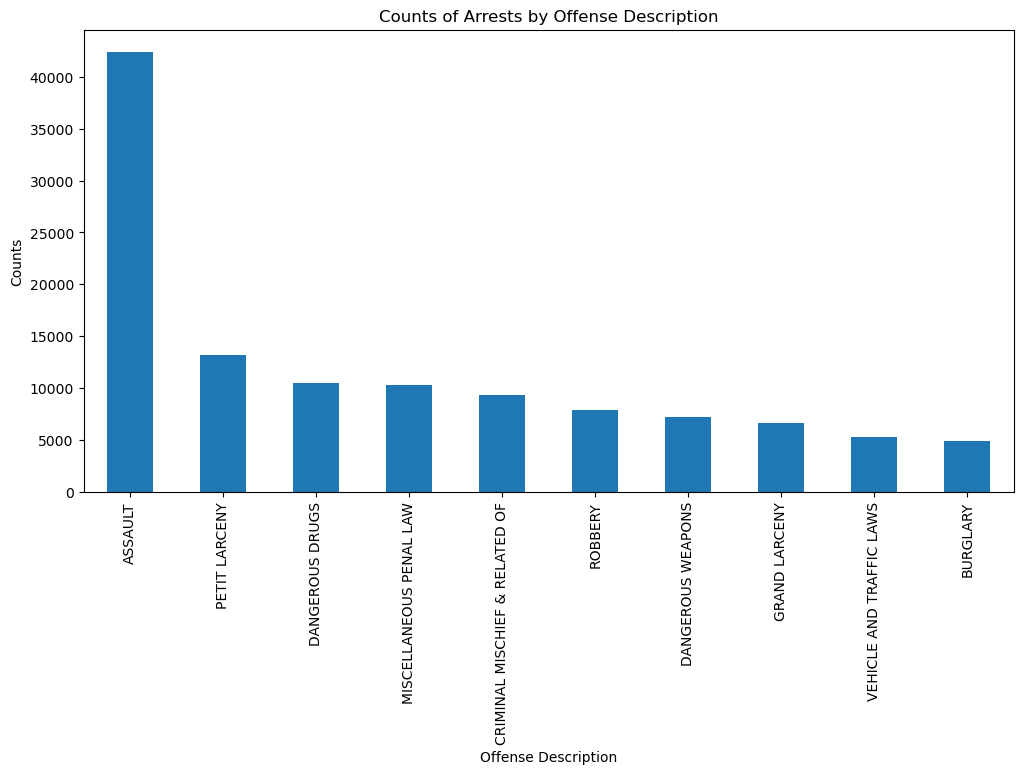

In [10]:
df2.plot(kind='bar', x='OFNS_DESC', y='counts', legend=False, figsize=(12,6))
plt.title('Counts of Arrests by Offense Description')
plt.xlabel('Offense Description')
plt.ylabel('Counts')

In [11]:
df.groupby('ARREST_BORO').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

,ARREST_BORO,counts
1,BROOKLYN,41550
2,MANHATTAN,39677
0,BRONX,34018
3,QUEENS,33051
4,STATEN ISLAND,7211


In [12]:
df.groupby('PERP_RACE').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

,PERP_RACE,counts
2,BLACK,77133
6,WHITE HISPANIC,38112
5,WHITE,17063
3,BLACK HISPANIC,13576
1,ASIAN / PACIFIC ISLANDER,8593
4,UNKNOWN,587
0,AMERICAN INDIAN/ALASKAN NATIVE,443


In [13]:
df.groupby('PERP_SEX').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

,PERP_SEX,counts
1,MALE,128910
0,FEMALE,26597


In [14]:
df.groupby('AGE_GROUP').size().reset_index(name='counts').sort_values(by='counts', ascending=False)  

,AGE_GROUP,counts
1,25-44,88850
2,45-64,30608
0,18-24,28951
4,<18,4800
3,65+,2298


In [15]:
df.groupby('ARREST_PRECINCT').size().reset_index(name='counts').sort_values(by='counts', ascending=False)  

,ARREST_PRECINCT,counts
7,14,4762
26,44,4387
46,75,4249
22,40,4070
29,47,3489
...,...,...
57,100,827
76,123,798
47,76,772
68,111,700


In [16]:
months_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
df3 = df.groupby('MONTH').size().reindex(months_order, fill_value=0)

In [17]:
df3

MONTH
January      13506
February     11653
March        13980
April        10424
May          11822
June         12850
July         13561
August       13745
September    13756
October      14453
November     13068
December     12689
dtype: int64

Text(0, 0.5, 'Counts')

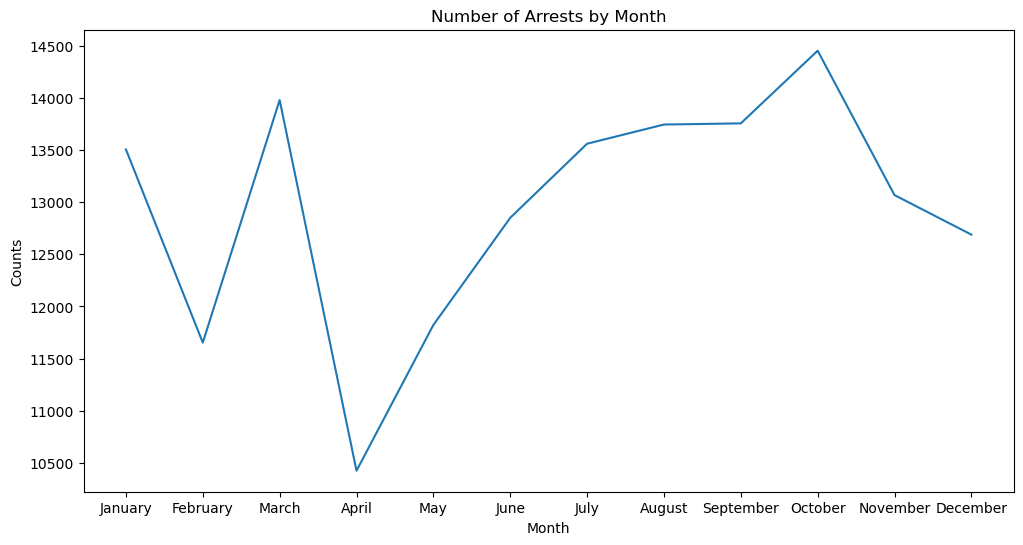

In [18]:
months_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
df3.plot(kind='line', x='MONTH', y='counts', legend=False, figsize=(12,6))
plt.xticks(range(len(months_order)), months_order)
plt.title('Number of Arrests by Month')
plt.xlabel('Month')
plt.ylabel('Counts')

In [19]:
df.select_dtypes(include=['object']) 

,ARREST_DATE,PD_DESC,OFNS_DESC,LAW_CAT_CD,ARREST_BORO,AGE_GROUP,PERP_SEX,PERP_RACE,New Georeferenced Column,MONTH
0,2021-01-01,ASSAULT 3,ASSAULT,MISDEMEANOR,BROOKLYN,25-44,MALE,WHITE HISPANIC,POINT (-73.93522525599997 40.69699455600005),January
1,2021-01-01,ASSAULT 3,ASSAULT,MISDEMEANOR,QUEENS,25-44,MALE,WHITE HISPANIC,POINT (-73.89957593999998 40.73365273100006),January
2,2021-01-01,"ASSAULT 2,1,UNCLASSIFIED",ASSAULT,FELONY,BRONX,25-44,MALE,WHITE HISPANIC,POINT (-73.87999831299999 40.86940749200004),January
3,2021-01-01,ASSAULT 3,ASSAULT,MISDEMEANOR,STATEN ISLAND,25-44,FEMALE,BLACK,POINT (-74.17125230499995 40.63898417600007),January
4,2021-01-01,ASSAULT 3,ASSAULT,MISDEMEANOR,BROOKLYN,25-44,MALE,WHITE HISPANIC,POINT (-74.01065912499998 40.636166049000046),January
...,...,...,...,...,...,...,...,...,...,...
155502,2021-12-31,"FORGERY,ETC.,UNCLASSIFIED-FELO",FORGERY,FELONY,QUEENS,18-24,MALE,WHITE HISPANIC,POINT (-73.89994899199996 40.70868945500007),December
155503,2021-12-31,"CRIMINAL MISCHIEF,UNCLASSIFIED 4",CRIMINAL MISCHIEF & RELATED OF,MISDEMEANOR,BRONX,25-44,MALE,WHITE HISPANIC,POINT (-73.91739228599994 40.81912706800006),December
155504,2021-12-31,"ASSAULT 2,1,UNCLASSIFIED",ASSAULT,FELONY,BROOKLYN,45-64,MALE,BLACK,POINT (-73.94778709999997 40.69554895700002),December
155505,2021-12-31,CRIMINAL CONTEMPT 1,MISCELLANEOUS PENAL LAW,FELONY,QUEENS,25-44,MALE,ASIAN / PACIFIC ISLANDER,POINT (-73.73476084899994 40.726293088000034),December
